In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

### Non LLM Workflow

In [2]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int
    eq: str
    d: float
    result: str

In [3]:
def show_equation(state: QuadState):
    eq = f'{state['a']}x2+{state["b"]}x+{state['c']}'

    return {'eq':eq}

def calculate_d(state: QuadState):
    d = state['b']**2-4*state['a']*state['c']

    return {'d':d}

In [4]:
def real_roots(state: QuadState):
    r1 = (-state['b']+(state['d']**(1/2)))/2*state['a']
    r2 = (-state['b']-(state['d']**(1/2)))/2*state['a']

    result = f'The roots are {r1} and {r2}'

    return {'result':result}

def repeated_roots(state: QuadState):
    r1 = (-state['b'])/2*state['a']

    result = f'The repeated root is {r1}'

    return {'result':result}

def no_real_roots(state: QuadState):
    result = f'No real roots'

    return {'result':result}

def check_condition(state: QuadState) -> Literal["real_roots","repeated_roots","no_real_roots"]:
    d = state['d']

    if d>0:
        return "real_roots"
    elif d==0:
        return "repeated_roots"
    elif d<0:
        return "no_real_roots"

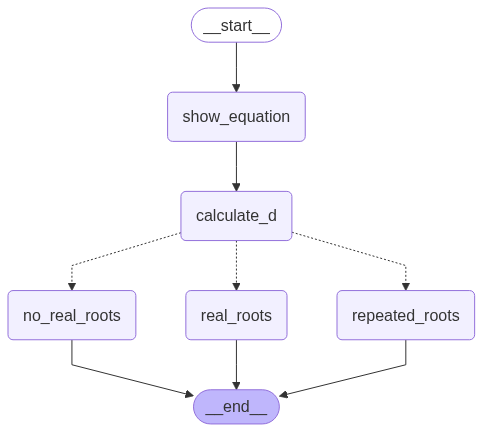

In [5]:
graph = StateGraph(QuadState)

graph.add_node('show_equation',show_equation)
graph.add_node('calculate_d',calculate_d)

graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation','calculate_d')

graph.add_conditional_edges('calculate_d',check_condition)

graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('no_real_roots',END)

workflow = graph.compile()
workflow

In [6]:
inital_state = {
    'a':2,
    'b':4,
    'c':2
}

final_state = workflow.invoke(inital_state)
final_state

{'a': 2,
 'b': 4,
 'c': 2,
 'eq': '2x2+4x+2',
 'd': 0,
 'result': 'The repeated root is -4.0'}

### LLM Workflow

In [50]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
import operator 
from dotenv import load_dotenv

load_dotenv()

True

In [51]:
model = ChatGroq(model="llama3-8b-8192", verbose=True)

In [52]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive","negative"] = Field(description="Sentiment of the review")

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [53]:
structured_model = model.with_structured_output(SentimentSchema)
diagnosis_model = model.with_structured_output(DiagnosisSchema)

In [54]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive","negative"]
    diagnosis: dict
    response: str

In [62]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website.
    """
    
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
    """
    response = diagnosis_model.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """
    response = model.invoke(prompt).content

    return {'response': response}

In [63]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

In [66]:
intial_state={
    'review': '''I was excited to try "QuickConnect" as a new social networking app, but my experience has been nothing short of frustrating. The app crashes constantly, especially when I try to upload a photo. It's almost impossible to have a smooth conversation—messages either take ages to send or don't go through at all. The user interface is cluttered and confusing, and I often find myself accidentally tapping on ads. I've tried reinstalling it multiple times, but the performance issues persist. It's a shame because the concept has potential, but the execution is terrible. I'm going back to my old app and won't be recommending this to anyone.'''
}
workflow.invoke(intial_state)


{'review': 'I was excited to try "QuickConnect" as a new social networking app, but my experience has been nothing short of frustrating. The app crashes constantly, especially when I try to upload a photo. It\'s almost impossible to have a smooth conversation—messages either take ages to send or don\'t go through at all. The user interface is cluttered and confusing, and I often find myself accidentally tapping on ads. I\'ve tried reinstalling it multiple times, but the performance issues persist. It\'s a shame because the concept has potential, but the execution is terrible. I\'m going back to my old app and won\'t be recommending this to anyone.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': "Dear [User],\n\nI'm so sorry to hear that you're experiencing a bug issue that's causing frustration and inconvenience. I can imagine how annoying it must be to encounter a problem that's disrupting your workflow or causing you s